Positional Encoding

In [ ]:
import torch
import torch.nn as nn
import numpy as np

In [ ]:
class PositionalEncoder(nn.Module):
    def __init__(self, d_model, seq_len, dropout):
        super(PositionalEncoder, self).__init__()
        self.d_model = d_model
        self.dropout = nn.Dropout(dropout)
        # Create positional encoding matrix
        pe = torch.zeros(seq_len, d_model)
        print(f"pe shape: {pe.shape}")
        
        # Create the position matrix
        position = torch.arange(0, seq_len).unsqueeze(1)
        print(f"position shape: {position.shape}")
        # Create the div_term matrix
        div_term = 1.0 / (10000.0 ** (torch.arange(0, d_model, 2).float() / d_model))
        print(f"div_term shape: {div_term.shape}")
        # Create the pe_pos matrix
        pe_pos = position.float() * div_term
        print(f"pe_pos shape: {pe_pos.shape}")

        # Apply sin to even indices
        pe[:, 0::2] = torch.sin(pe_pos)
        # Apply cos to odd indices
        pe[:, 1::2] = torch.cos(pe_pos)
        pe = pe.unsqueeze(0)
        print(f"pe shape: {pe.shape}")
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        print(f"x shape: {x.shape}")
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

pe shape: torch.Size([32, 100])
position shape: torch.Size([32, 1])
div_term shape: torch.Size([50])
pe_pos shape: torch.Size([32, 50])
x shape: torch.Size([1, 32, 100])


<Figure size 1500x500 with 0 Axes>

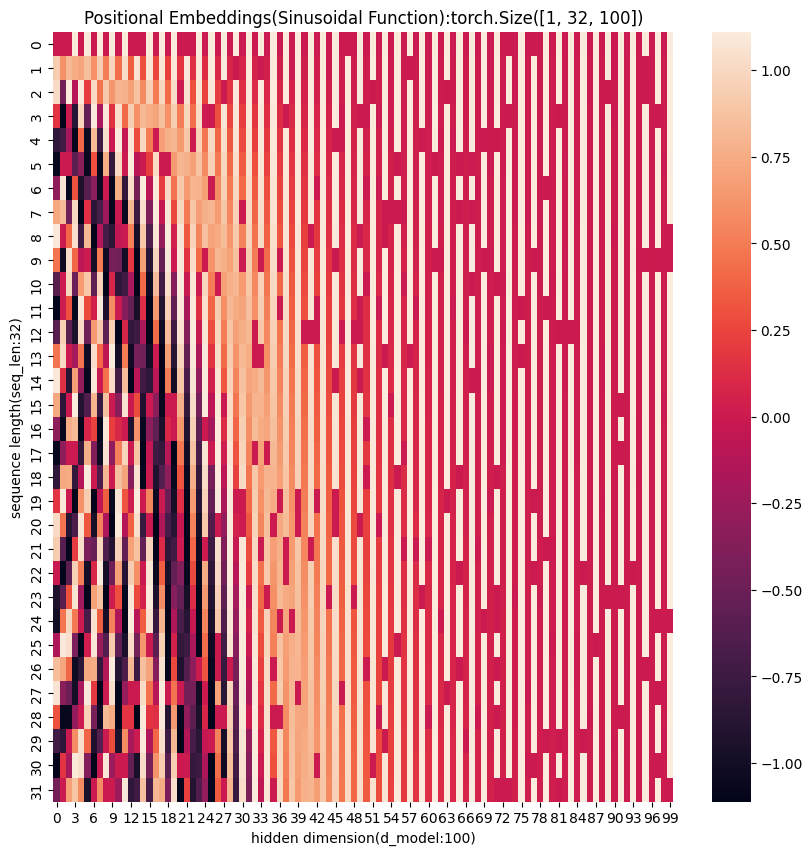

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


d_model = 100
seq_len = 32
drop_out = 0.1
# Create positional encoder
pe = PositionalEncoder(d_model, seq_len, drop_out)
x = torch.zeros(1, seq_len, d_model)
pe_embed = pe(x)
plt.figure(figsize=(15, 5))
plt.figure(figsize=(10, 10))
sns.heatmap(pe_embed.squeeze().cpu().numpy())  # 100x32 matrix
plt.title(f"Positional Embeddings(Sinusoidal Function):{pe_embed.shape}")
plt.xlabel(f"hidden dimension(d_model:{d_model})")
plt.ylabel(f"sequence length(seq_len:{seq_len})")
plt.show()
